# Comparison of Autoencoders' Performance on Various Datasets

In this notebook we compare the performance of the autoencoders to identify their capability to represent data in the latent space properly. This assessment will help us to decide which type of autoencoder best fits in the data privacy process during the counterfactual generation process.

In [169]:
import sys
dice_path = "/Users/volk/Documents/bau24-25/thesis/repos/DiCE-X"
sys.path.insert(0, dice_path)

In [170]:
import dice_ml_x
import importlib
import dice_ml_x.autoencoders.dp_s_ae
importlib.reload(dice_ml_x.autoencoders.dp_s_ae)
from dice_ml_x.autoencoders.dp_s_ae import DPStandardAutoEncoder
from dice_ml_x import DiceX, Data
import torch
import matplotlib.pyplot as plt
from dice_ml_x.utils import helpers
from dice_ml_x.benchmarking import Benchmarking
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from ucimlrepo import fetch_ucirepo
import pandas as pd

In [171]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


After importing the necessary modules, and making the notebook adaptable to the changes in the imported modules we load the datasets that we will experiment with during this notebook. The datasets are COMPAS, Adult Income, Lending Club, and German Credit Datasets which are accessible publicly on the internet.
**COMPAS**: 

In [190]:
all_datasets = {
    "compas-recidivism": {
        "data": helpers.load_compas_dataset(),
        "target": "twoyearrecid"
    },
    "adult-income": {
        "data": helpers.load_adult_income_dataset(),
        "target": "income"
    },
    "lending-club": {
        "data": helpers.load_lending_club_dataset(),
        "target": "loan_status"
    },
    "german-credit": {
        "data": helpers.load_german_credit_dataset(),
        "target": "credit_risk"
    }
}

/Users/volk/Documents/bau24-25/thesis/repos/DiCE-X/dice_ml_x/utils/helpers.py:56: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[byte_string_cols] = df[byte_string_cols].applymap(lambda x: int(x.decode("utf-8")))
/Users/volk/Documents/bau24-25/thesis/repos/DiCE-X/dice_ml_x/utils/helpers.py:355: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  adult_data = adult_data.replace({'income': {'<=50K': 0, '>50K': 1}})
/Users/volk/Documents/bau24-25/thesis/repos/DiCE-X/dice_ml_x/utils/helpers.py:266: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate obj

In [66]:
diabetes_130_us_hospitals_for_years_1999_2008 = fetch_ucirepo(id=296) 
X = diabetes_130_us_hospitals_for_years_1999_2008.data.features 
y = diabetes_130_us_hospitals_for_years_1999_2008.data.targets
X['readmitted'] = y
X.head()

/Users/volk/Documents/bau24-25/thesis/repos/DiCE-X/.venv/lib/python3.12/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)
/var/folders/8m/6z48y8212x782rk9dpgmm9lm0000gn/T/ipykernel_3031/3338755145.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['readmitted'] = y


,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [44]:
all_datasets['lending-club']['data'].count()

employment_years       39715
num_open_credit_acc    39715
annual_income          39715
loan_grade             39715
credit_history         39715
purpose                39715
home                   39715
addr_state             39715
loan_status            39715
dtype: int64

# VARIATIONAL AUTO-ENCODER

Epoch 1/10: 100%|██████████| 50/50 [00:00<00:00, 1074.71it/s, loss=0.1161]


Epoch 01 | loss: 0.1819


Epoch 2/10: 100%|██████████| 50/50 [00:00<00:00, 1032.37it/s, loss=0.1281]


Epoch 02 | loss: 0.1212


Epoch 3/10: 100%|██████████| 50/50 [00:00<00:00, 996.25it/s, loss=0.1124]


...

Epoch 08 | loss: 0.0631


Epoch 9/10: 100%|██████████| 50/50 [00:00<00:00, 1034.41it/s, loss=0.0598]


Epoch 09 | loss: 0.0567


Epoch 10/10: 100%|██████████| 50/50 [00:00<00:00, 1018.14it/s, loss=0.0500]


Epoch 10 | loss: 0.0516
DP training finished ✓


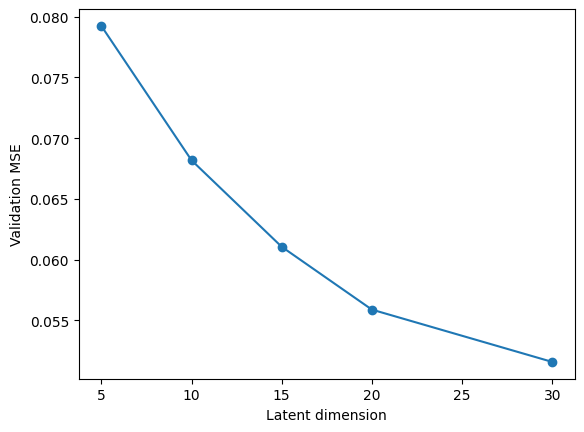

In [191]:
mapping = {"<30": 1, "NO": 0, ">30": 1}
X_df = X.copy()
X_df["readmitted"] = X_df["readmitted"].map(mapping).astype(int)
german_credit_df = all_datasets["german-credit"]["data"]

cont_feats = german_credit_df.select_dtypes(include=[np.number]).columns.difference(['credit_risk']).tolist()
cat_features = german_credit_df.columns.difference(cont_feats + ['credit_risk'])
benchmarking = Benchmarking(None, None)

scaler = MinMaxScaler()

train_dataloader, test_dataloader, train_df, test_df, y_train_df, \
    y_test_df, pipeline, pyt_scaler, pyt_encoder, pyt_label_encoder = benchmarking.preprocess_data('PYT', german_credit_df, cont_feats, 'credit_risk', 16, pyt_scaler=scaler)

dummy_batch = next(iter(train_dataloader))[0]
input_feat = dummy_batch.shape[1]



latent_sizes = [5, 10, 15, 20, 30]
errors = []
best_error = np.inf
models = []
for k in latent_sizes:
    dp_ae = DPStandardAutoEncoder(input_feat, latent_dim=k)
    dp_ae.train_autoencoder(train_dataloader, epochs=10, batch_size=64,
        epsilon=1.0,
        learning_rate=1e-3)
    history = dp_ae.history
    val_mse = history['loss'][-1]
    models.append(dp_ae)
    errors.append(val_mse)

plt.plot(latent_sizes, errors, marker='o')
plt.xlabel("Latent dimension")
plt.ylabel("Validation MSE")
plt.show()

In [124]:
next(iter(train_dataloader))[0].shape

torch.Size([16, 2470])

In [125]:
train_df.shape

(81412, 48)

In [174]:
from kneed import KneeLocator

kl = KneeLocator(latent_sizes, errors,  curve='convex', direction='decreasing')
print("Elbow at latent_dim =", kl.knee)
best_model_idx = latent_sizes.index(kl.knee)
best_model = models[best_model_idx]

Elbow at latent_dim = 15


In [175]:
best_model

DPStandardAutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=61, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=15, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=61, bias=True)
    (3): Sigmoid()
  )
)

In [76]:
%reload_ext autoreload

In [200]:
pyt_trainer, dice_model = benchmarking.train_pytorch_model(train_dataloader, test_dataloader)

In [201]:
pyt_trainer.history['train_acc']

[0.69375,
 0.7,
 0.7,
 0.7025,
 0.7275,
 0.7525,
 0.75625,
 0.765,
 0.765,
 0.7775,
 0.77125,
 0.77875,
 0.7825,
 0.78625,
 0.79375,
 0.7875,
 0.795,
 0.79125,
 0.79625,
 0.7925]

In [192]:
pyt_trainer.model.eval()
dummy_sample = next(iter(test_dataloader))[0][1]
with torch.no_grad():
    print(pyt_trainer.model(dummy_sample))

tensor([ 1.1769, -1.1417])


In [188]:
%xmode Verbose

Exception reporting mode: Verbose


In [ ]:
from sklearn.impute import SimpleImputer

numerical_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

x_test[cont_feats] = numerical_imputer.fit_transform(test_df[cont_feats])
x_test[cat_features] = cat_imputer.fit_transform(test_df[cat_features])
x_test = x_test.drop(columns=['readmitted'])


KeyError: "['readmitted'] not found in axis"

In [185]:
gaussian_kwargs = {
    'continuous_features': cont_feats,
    'categorical_features': cat_features,
    'std_dev': 0.3
}
x_test = test_df.drop(columns="credit_risk")
d = dice_ml_x.Data(dataframe=train_df, continuous_features=cont_feats, 
                   categorical_features=cat_features, outcome_name='credit_risk')

m = dice_ml_x.Model(model=dice_model, backend='DP_PYT',  func="ohe-min-max")
exp = dice_ml_x.DiceX(d, m, dp_autoencoder=best_model, method="gradient")
from collections import OrderedDict
exp_options = OrderedDict(query_instances=x_test[1:2], total_CFs=10, max_iter=5000, desired_class="opposite",
                                        perturbation_method="gaussian", algorithm="DiverseCF",
                                        learning_rate=1.0, **gaussian_kwargs)
dice_exp = exp.generate_counterfactuals(**exp_options)
# highlight only the changes
dice_exp.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:31<00:00, 31.97s/it]

No Counterfactuals found for the given configuation,  perhaps try with different values of proximity (or diversity) weights or learning rate... ; total time taken: 00 min 31 sec


UserConfigValidationException: No counterfactuals found for any of the query points! Kindly check your configuration.

In [141]:
exp.get_validity_percentage()

70.0

In [78]:
# Get a batch from test dataloader
batch = next(iter(test_dataloader))

# If it's a list or tuple, get the first item (assuming no labels)
x_true = batch[0] if isinstance(batch, (list, tuple)) else batch

# Ensure it's a tensor
if isinstance(x_true, list):
    x_true = torch.stack(x_true)


# Run reconstruction
x_reconstructed, _ = dp_ae(x_true)

# Compute reconstruction loss
mse = torch.nn.MSELoss()
reconstruction_loss = mse(x_reconstructed, x_true).item()
print(f"Reconstruction MSE on test batch: {reconstruction_loss:.5f}")

Reconstruction MSE on test batch: 0.00863


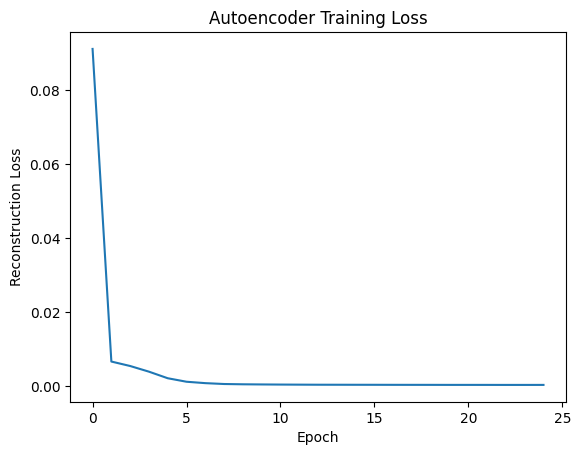

In [82]:
import matplotlib.pyplot as plt

plt.plot(dp_ae.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("Autoencoder Training Loss")
plt.show()


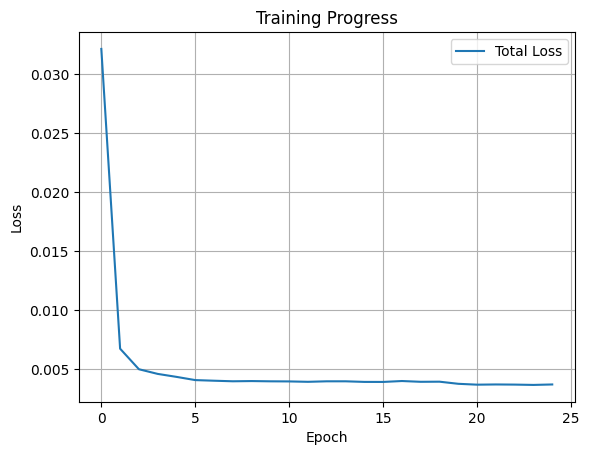

In [62]:
import matplotlib.pyplot as plt

plt.plot(dp_ae._history['loss'], label='Total Loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Progress')
plt.grid(True)
plt.show()

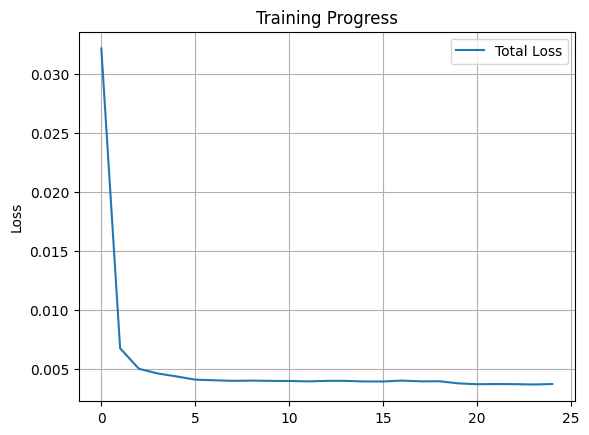

In [63]:
plt.plot(dp_ae._history['loss'], label='Total Loss')
plt.legend()
plt.ylabel('Loss')
plt.title('Training Progress')
plt.grid(True)
plt.show()

In [139]:
len(X_df.columns)

48

Epoch 100, Loss: 0.0082
Epoch 200, Loss: 0.0038
Epoch 300, Loss: 0.0019
Epoch 400, Loss: 0.0010
Epoch 500, Loss: 0.0006
Epoch 600, Loss: 0.0004
Epoch 700, Loss: 0.0003
Epoch 800, Loss: 0.0002
Epoch 900, Loss: 0.0002
Epoch 1000, Loss: 0.0001


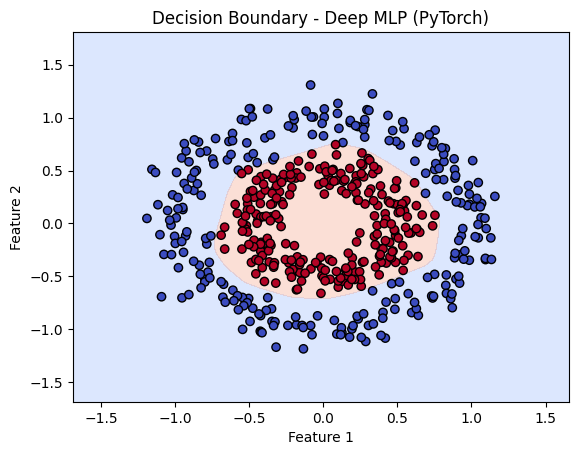

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
import numpy as np

X, y = make_circles(n_samples=500, noise=0.1, factor=0.5, random_state=42)
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

class DeepMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

model = DeepMLP()

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(1000):
    y_pred = model(X_tensor)
    loss = criterion(y_pred, y_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 100 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                         np.linspace(y_min, y_max, 400))
    
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.tensor(grid, dtype=torch.float32)

    with torch.no_grad():
        Z = model(grid_tensor).reshape(xx.shape).numpy()

    plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], alpha=0.3, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
    plt.title("Decision Boundary - Deep MLP (PyTorch)")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

plot_decision_boundary(model, X, y)
